# WEEK04 ablation / RQ analysis

For RQ1: join `WEEK03_Results` with STL profiles and compute
`Δ = MSE(DLinear) - MSE(NLinear)` (negative means DLinear wins).

MA kernel and lookback ablations are stubs for Friday.


## 0. Setup and sanity


In [108]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [109]:
import pandas as pd
from src.config import (
    settings,
    LTSF_LOOKBACKS,
    LTSF_HORIZONS,
    VIC_LOOKBACKS,
    TRAIN_PROTOCOL,
)
from src.pipeline.eval import (
    build_baseline_results,
    dataset_mean_gap,
    heatmap_delta,
    join_profiles,
    mse_gap,
    scatter_char_vs_delta,
)


In [110]:
data_profiles = pd.read_csv(settings.profiles_csv)
grid_results = pd.read_csv(settings.grid_result_csv)


In [111]:
assert set(grid_results.dataset.unique()) == set(data_profiles.dataset.unique())
for dataset in grid_results.dataset.unique():
    settings.get_spec(dataset)

MODELS = ("Linear", "NLinear", "DLinear")
LTSF_DATASETS = [s["name"] for s in settings.DATASET_SPECS if s["name"] != "VIC"]
n_lrs = len(TRAIN_PROTOCOL["lrs"])
n_ltsf = (
    len(LTSF_DATASETS) * len(LTSF_LOOKBACKS) * len(LTSF_HORIZONS) * len(MODELS) * n_lrs
)
n_vic = len(VIC_LOOKBACKS) * len(MODELS) * n_lrs
expected_num_rows = n_ltsf + n_vic
assert len(grid_results) == expected_num_rows, (len(grid_results), expected_num_rows)
print("sanity ok:", len(grid_results), "grid rows,", len(data_profiles), "profiles")


sanity ok: 756 grid rows, 6 profiles


## 1. Baseline results (best lr into `WEEK03_Results.csv`)

`loss` is test MSE. One row per `(model, dataset, lookback, horizon)`.


In [112]:
results = build_baseline_results(grid_results)
results.to_csv(settings.baseline_results_csv, index=False)
print(settings.baseline_results_csv)
results.groupby("model").size()


/mnt/c/HOCTAP/AIO_2026/module4/research/DLinear_NLinear/Working_Files/TA_reports/WEEK03_Results.csv


model
DLinear    84
Linear     84
NLinear    84
dtype: int64

## 2. RQ1: Δ and data-char join

`Δ = loss(DLinear) - loss(NLinear)`, then merge `F_T` / `F_S` from the profiles.


In [113]:
gap = mse_gap(results)
joined = join_profiles(gap, data_profiles)
mean_gap = dataset_mean_gap(joined)

n_d = int((joined["delta"] < 0).sum())
n_n = int((joined["delta"] > 0).sum())
n_tie = int((joined["delta"] == 0).sum())
print(
    f"cells: {len(joined)} | DLinear better: {n_d} | NLinear better: {n_n} | tie: {n_tie}"
)
mean_gap


cells: 84 | DLinear better: 32 | NLinear better: 52 | tie: 0


,dataset,delta,F_T,F_S,adf_pvalue
0,ETTh1,0.029730,0.969148,0.277475,8.301649e-03
1,ETTh2,0.017707,0.955784,0.652652,5.816097e-03
2,Electricity,-0.008139,0.736982,0.627806,3.145310e-26
3,Exchange-Rate,-0.427861,0.997393,0.000000,4.166462e-01
4,VIC,-0.000032,0.998854,0.000000,9.942172e-01
5,Weather,0.004979,0.971120,0.875593,0.000000e+00


## 3. RQ1 plots


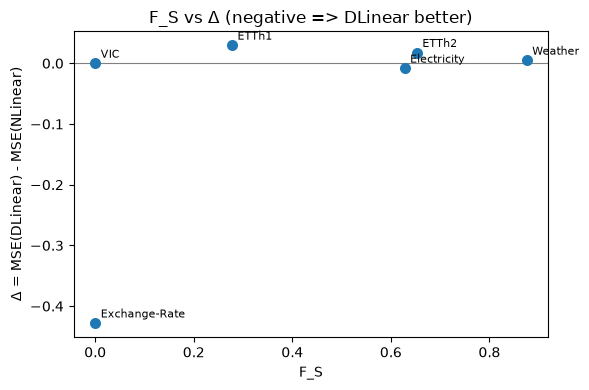

In [114]:
ax = scatter_char_vs_delta(joined, char="F_S", aggregate=True)
ax.figure.tight_layout()


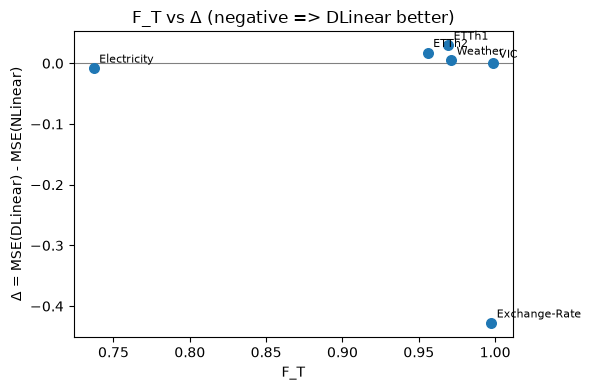

In [115]:
ax = scatter_char_vs_delta(joined, char="F_T", aggregate=True)
ax.figure.tight_layout()


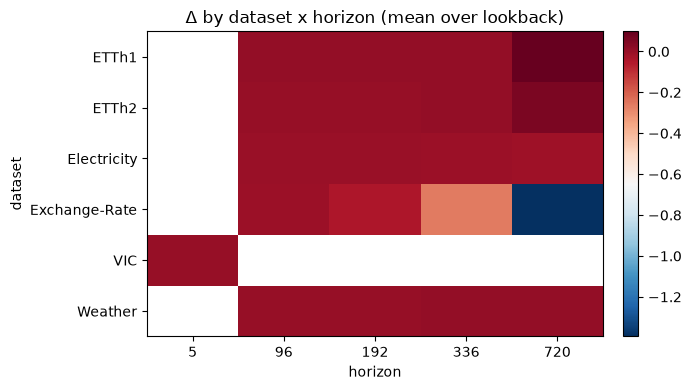

In [116]:
ax = heatmap_delta(joined, how="mean")
ax.figure.tight_layout()


## MA kernel sweep (TODO)

Run DLinear with a few MA kernel sizes on at least two high-`F_S` datasets and one low-`F_S` dataset.


## Lookback sensitivity, RQ2 (TODO)

Plot MSE against lookback `L` for NLinear and DLinear on each dataset, then compare with the profiles.
